In [34]:
# HIGH-RISK PATIENT INVESTIGATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [35]:
# Load config paths
BASE_DIR = Path.cwd().parent

RAW_DATA_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"

PATIENTS_FILE = RAW_DATA_DIR / "patients.csv"
ADMISSIONS_FILE = RAW_DATA_DIR / "admissions.csv"
VITALS_FILE = RAW_DATA_DIR / "vitals.csv"
LABS_FILE = RAW_DATA_DIR / "lab_results.csv"
MEDICATIONS_FILE = RAW_DATA_DIR / "medications.csv"
DIAGNOSES_FILE = RAW_DATA_DIR / "diagnoses.csv"
ED_VISITS_FILE = RAW_DATA_DIR / "ed_visits.csv"
READMISSIONS_FILE = RAW_DATA_DIR / "readmissions.csv"

print("BASE_DIR:", BASE_DIR)
print("RAW_DATA_DIR:", RAW_DATA_DIR)
print("Patients file exists:", PATIENTS_FILE.exists())

BASE_DIR: c:\Users\lapto\OneDrive\Predictive Healthcare\Health-Care-predictive-Analysis
RAW_DATA_DIR: c:\Users\lapto\OneDrive\Predictive Healthcare\Health-Care-predictive-Analysis\data\raw
Patients file exists: True


In [36]:
# Load data
patients = pd.read_csv(PATIENTS_FILE)
admissions = pd.read_csv(ADMISSIONS_FILE)
vitals = pd.read_csv(VITALS_FILE)
labs = pd.read_csv(LABS_FILE)
medications = pd.read_csv(MEDICATIONS_FILE)
diagnoses = pd.read_csv(DIAGNOSES_FILE)

print("Patients:", patients.shape)
print("Admissions:", admissions.shape)
print("Vitals:", vitals.shape)
print("Labs:", labs.shape)
print("Medications:", medications.shape)
print("Diagnoses:", diagnoses.shape)

Patients: (5000, 27)
Admissions: (8500, 22)
Vitals: (41382, 15)
Labs: (417334, 10)
Medications: (51112, 12)
Diagnoses: (29648, 7)


In [37]:
# Inspect columns

print("\nPatients columns:")
print(patients.columns.tolist())

print("\nAdmissions columns:")
print(admissions.columns.tolist())

print("\nVitals columns:")
print(vitals.columns.tolist())

print("\nLabs columns:")
print(labs.columns.tolist())

print("\nMedications columns:")
print(medications.columns.tolist())

print("\nDiagnoses columns:")
print(diagnoses.columns.tolist())


Patients columns:
['patient_id', 'mrn', 'first_name', 'last_name', 'date_of_birth', 'age', 'gender', 'ethnicity', 'insurance_type', 'zip_code', 'primary_hospital', 'has_diabetes', 'has_hypertension', 'has_heart_disease', 'has_copd', 'has_ckd', 'has_depression', 'has_obesity', 'has_cancer', 'charlson_comorbidity_index', 'num_prior_admissions', 'num_prior_ed_visits', 'smoking_status', 'alcohol_use', 'language_preference', 'social_support_score', 'registered_date']

Admissions columns:
['admission_id', 'patient_id', 'admission_date', 'discharge_date', 'length_of_stay_days', 'admission_type', 'admission_source', 'hospital', 'ward', 'primary_diagnosis_icd', 'primary_diagnosis_desc', 'drg_code', 'icu_admitted', 'icu_days', 'surgery_performed', 'num_procedures', 'attending_physician_id', 'discharge_disposition', 'total_charges_usd', 'insurance_paid_usd', 'readmitted_within_30d', 'readmission_reason']

Vitals columns:
['vital_id', 'admission_id', 'patient_id', 'measured_at', 'systolic_bp', 'd

In [38]:
# Create admission-level features

# Patient-level risk features
patient_features = patients[
    [
        "patient_id",
        "age",
        "gender",
        "insurance_type",
        "has_diabetes",
        "has_hypertension",
        "has_heart_disease",
        "has_copd",
        "has_ckd",
        "has_depression",
        "has_obesity",
        "has_cancer",
        "charlson_comorbidity_index",
        "num_prior_admissions",
        "num_prior_ed_visits",
        "smoking_status",
        "social_support_score"
    ]
]

# Admission-level risk features
admission_features = admissions[
    [
        "admission_id",
        "patient_id",
        "admission_type",
        "admission_source",
        "hospital",
        "ward",
        "length_of_stay_days",
        "icu_admitted",
        "icu_days",
        "surgery_performed",
        "num_procedures",
        "discharge_disposition",
        "total_charges_usd",
        "readmitted_within_30d"
    ]
]

# Vitals summary by admission
vitals_summary = vitals.groupby("admission_id").agg(
    avg_systolic_bp=("systolic_bp", "mean"),
    avg_diastolic_bp=("diastolic_bp", "mean"),
    avg_heart_rate=("heart_rate", "mean"),
    max_heart_rate=("heart_rate", "max"),
    avg_respiratory_rate=("respiratory_rate", "mean"),
    avg_temperature_c=("temperature_c", "mean"),
    max_temperature_c=("temperature_c", "max"),
    avg_spo2=("spo2_percent", "mean"),
    min_spo2=("spo2_percent", "min"),
    avg_news2_score=("news2_score", "mean"),
    max_news2_score=("news2_score", "max"),
    avg_pain_score=("pain_score", "mean")
).reset_index()

# Lab abnormality features
labs["is_abnormal_lab"] = labs["flag"].isin(["H", "L"]).astype(int)

labs_summary = labs.groupby("admission_id").agg(
    total_lab_tests=("lab_id", "count"),
    abnormal_lab_count=("is_abnormal_lab", "sum"),
    avg_lab_value=("value", "mean")
).reset_index()

# Medication features
med_summary = medications.groupby("admission_id").agg(
    medication_count=("medication_id", "count"),
    high_alert_med_count=("is_high_alert", "sum")
).reset_index()

# Diagnosis features
diagnosis_summary = diagnoses.groupby("admission_id").agg(
    diagnosis_count=("diagnosis_id", "count")
).reset_index()

In [28]:
# Merge into one investigation dataset
risk_df = admission_features.merge(patient_features, on="patient_id", how="left")
risk_df = risk_df.merge(vitals_summary, on="admission_id", how="left")
risk_df = risk_df.merge(labs_summary, on="admission_id", how="left")
risk_df = risk_df.merge(med_summary, on="admission_id", how="left")
risk_df = risk_df.merge(diagnosis_summary, on="admission_id", how="left")

print("\nHigh-risk investigation dataset:")
print(risk_df.shape)
display(risk_df.head())


High-risk investigation dataset:
(8500, 48)


,admission_id,patient_id,admission_type,admission_source,hospital,ward,length_of_stay_days,icu_admitted,icu_days,surgery_performed,...,min_spo2,avg_news2_score,max_news2_score,avg_pain_score,total_lab_tests,abnormal_lab_count,avg_lab_value,medication_count,high_alert_med_count,diagnosis_count
0,ADM-0000001,PAT-004458,Emergency,Physician Referral,MHN Cambridge,Geriatrics,9,1,3,1,...,93.2,2.333333,6,4.833333,51,30,53.368235,9,3,5
1,ADM-0000002,PAT-001044,Urgent,Transfer,MHN Quincy,Cardiology,6,0,0,0,...,92.8,2.800000,7,5.400000,39,9,34.961282,2,1,3
2,ADM-0000003,PAT-000197,Observation,Transfer,MHN Fenway,ICU,3,0,0,1,...,91.7,2.000000,3,3.250000,18,11,49.386667,4,2,1
3,ADM-0000004,PAT-001374,Emergency,Direct Admission,MHN Cambridge,Orthopedics,6,0,0,1,...,91.8,1.857143,4,5.285714,59,29,38.702373,4,1,1
4,ADM-0000005,PAT-004116,Elective,Physician Referral,MHN Fenway,Respiratory,4,1,3,0,...,93.3,3.166667,6,5.166667,70,34,36.149000,2,0,3


In [39]:
# Define possible high-risk patients
risk_df["risk_score"] = (
    (risk_df["age"] >= 65).astype(int) +
    (risk_df["charlson_comorbidity_index"] >= 3).astype(int) +
    (risk_df["num_prior_admissions"] >= 2).astype(int) +
    (risk_df["num_prior_ed_visits"] >= 2).astype(int) +
    (risk_df["icu_admitted"] == 1).astype(int) +
    (risk_df["max_news2_score"] >= 5).astype(int) +
    (risk_df["min_spo2"] < 92).astype(int) +
    (risk_df["high_alert_med_count"] >= 1).astype(int)
)

print("\nHigh-risk patient distribution:")
print(risk_df["risk_score"].value_counts(normalize=True) * 100)


High-risk patient distribution:
risk_score
3    28.588235
2    22.411765
4    22.352941
5    11.188235
1     9.376471
6     3.505882
0     1.929412
7     0.576471
8     0.070588
Name: proportion, dtype: float64


In [40]:
risk_df["high_risk_patient"] = (
    risk_df["risk_score"] >= 3
).astype(int)

In [41]:
# Feature investigation

numeric_cols = risk_df.select_dtypes(include=["int64", "float64"]).columns

risk_summary = risk_df.groupby("high_risk_patient")[numeric_cols].mean().T
display(risk_summary)


high_risk_patient,0,1
length_of_stay_days,5.582345,5.977991
icu_admitted,0.098395,0.292687
icu_days,0.567690,1.737309
surgery_performed,0.359037,0.359070
num_procedures,3.515003,3.438587
total_charges_usd,18668.306507,18105.492226
readmitted_within_30d,0.183182,0.228612
age,54.077809,65.968051
has_diabetes,0.280530,0.419773
has_hypertension,0.369505,0.431310


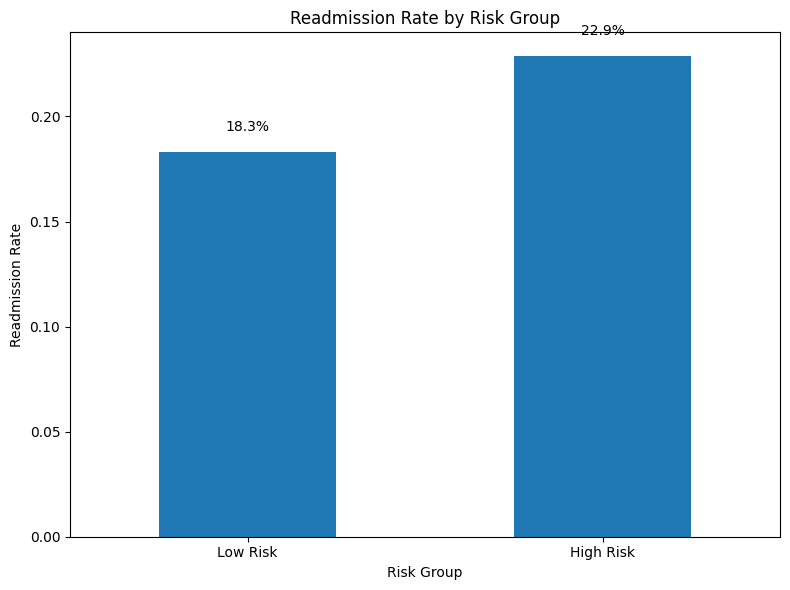

In [42]:
readmission_rate = (
    risk_df.groupby("high_risk_patient")["readmitted_within_30d"]
    .mean()
)

ax = readmission_rate.plot(
    kind="bar",
    figsize=(8,6)
)

plt.title("Readmission Rate by Risk Group")
plt.xlabel("Risk Group")
plt.ylabel("Readmission Rate")
plt.xticks([0,1], ["Low Risk", "High Risk"], rotation=0)

for i, v in enumerate(readmission_rate):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.show()

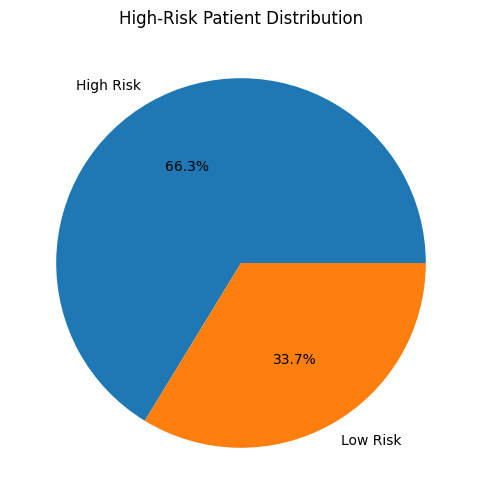

In [46]:
risk_counts = risk_df["high_risk_patient"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    risk_counts,
    labels=["High Risk", "Low Risk"],
    autopct="%1.1f%%"
)

plt.title("High-Risk Patient Distribution")
plt.show()

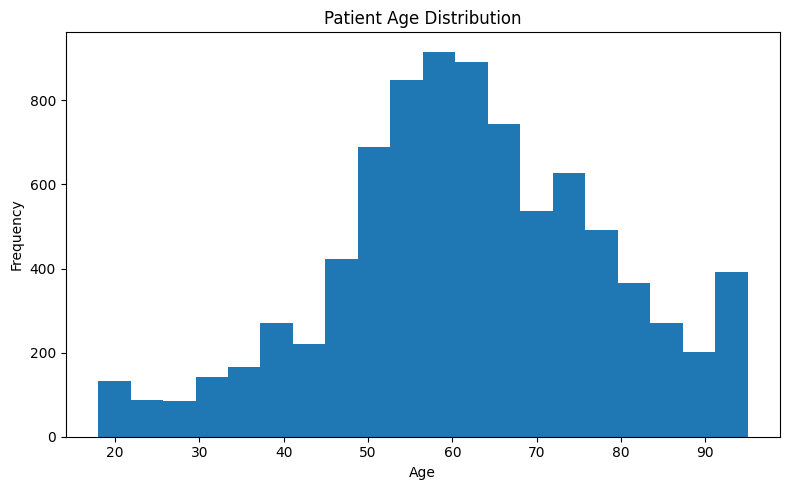

In [47]:
plt.figure(figsize=(8,5))
plt.hist(risk_df["age"], bins=20)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

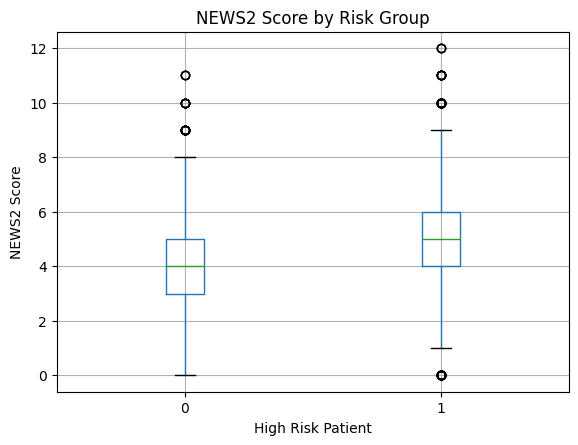

In [48]:
plt.figure(figsize=(8,5))

risk_df.boxplot(
    column="max_news2_score",
    by="high_risk_patient"
)

plt.title("NEWS2 Score by Risk Group")
plt.suptitle("")
plt.xlabel("High Risk Patient")
plt.ylabel("NEWS2 Score")
plt.show()

In [ ]:
# Save investigation dataset

OUTPUT_FILE = BASE_DIR / "data" / "processed" / "high_risk_patient_investigation.csv"
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

risk_df.to_csv(OUTPUT_FILE, index=False)

print("Saved:", OUTPUT_FILE)

Saved: c:\Users\lapto\OneDrive\Predictive Healthcare\Health-Care-predictive-Analysis\data\processed\high_risk_patient_investigation.csv
